Exercício Prático — Aula 03
Use NumPy puro (sem .groupby(), sem .value_counts() do pandas) para responder as perguntas abaixo sobre a base_rh.

Passos
Extraia como arrays NumPy as colunas Salario e Idade. Mostre shape, dtype, min() e max() de cada um.

Calcule sem loop: média, mediana, desvio padrão e soma total dos salários. Compare com os valores do df.describe() — devem ser iguais.

Slicing: selecione os 10 maiores salários usando np.argsort(). Exiba os valores.

Use np.where() para criar o array geração:

"Boomer" se Idade >= 60
"Gen X" se Idade >= 44
"Millennial" se Idade >= 28
"Gen Z" se Idade < 28 (Use np.select() com as quatro condições.)
Use máscara booleana (sem groupby) para calcular o salário médio de cada geração.

Broadcasting: crie o array salario_normalizado subtraindo a média e dividindo pelo desvio padrão (padronização z-score). Verifique que a média resultante é ~0 e o desvio é ~1.

Gráfico 1 — histograma dos salários com bins = np.linspace(salarios.min(), salarios.max(), 12).

Gráfico 2 — barras horizontais com o salário médio de cada geração calculado no passo 5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

URL = (
    "https://raw.githubusercontent.com/"
    "cfneves/turma-visualizacao-de-dados/"
    "master/alunos/Andressa_Alves/semana_04/bases/base_rh.xlsx"
)

df = pd.read_excel(URL)
df.head()

df['Data_Admissao'] = pd.to_datetime(
    df['Data_Admissao'], 
    format='%d/%m/%Y',                                 
     errors='coerce')

print(f'Dataset: {df.shape[0]} linhas x {df.shape[1]} colunas')
print(df.dtypes)

Dataset: 1000 linhas x 10 colunas
ID_Funcionario             int64
Nome                         str
Departamento                 str
Cargo                        str
Salario                  float64
Data_Admissao     datetime64[us]
Genero                       str
Idade                      int64
Estado_Civil                 str
Status                       str
dtype: object


Salários: (1000,) float64 2000.71 14954.51
Idades:    (1000,) int64 18 65

Estatísticas dos salários:
  Média:   R$ 8,579.95
  Mediana: R$ 8,571.13
  Desvio:  R$ 3,655.54
  Soma:    R$ 8,579,951.78

Compare com df.describe():
count     1000.000000
mean      8579.951780
std       3657.365307
min       2000.710000
25%       5564.545000
50%       8571.135000
75%      11554.630000
max      14954.510000
Name: Salario, dtype: float64

10 maiores salários:
[14954.51 14951.53 14948.18 14942.48 14942.39 14923.61 14918.19 14914.63
 14912.48 14904.99]
Boomer      : R$ 8,223.51  (n=112)
Gen X       : R$ 8,458.02  (n=333)
Millennial  : R$ 8,814.86  (n=362)
Gen Z       : R$ 8,556.57  (n=193)
Média após normalização : -0.000000
Desvio após normalização: 1.000000


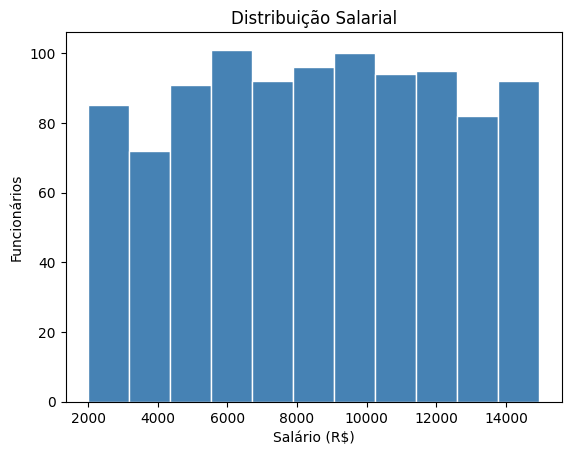

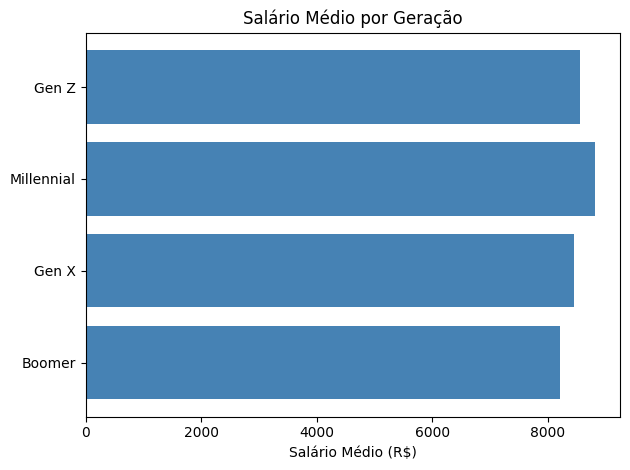

In [2]:
# 1) Extraindo arrays NumPy
salarios = df['Salario'].to_numpy()
idades = df['Idade'].to_numpy()

print('Salários:', salarios.shape, salarios.dtype, salarios.min(), salarios.max())
print('Idades:   ', idades.shape, idades.dtype, idades.min(), idades.max())

# 2) Estatísticas de salários sem loop
media_sal = np.mean(salarios)
mediana_sal = np.median(salarios)
desvio_sal = np.std(salarios, ddof=0)
soma_sal = np.sum(salarios)

print('\nEstatísticas dos salários:')
print(f'  Média:   R$ {media_sal:,.2f}')
print(f'  Mediana: R$ {mediana_sal:,.2f}')
print(f'  Desvio:  R$ {desvio_sal:,.2f}')
print(f'  Soma:    R$ {soma_sal:,.2f}')

print('\nCompare com df.describe():')
print(df['Salario'].describe())

# 3) Dez maiores salários usando np.argsort()
indices_ordenados = np.argsort(salarios)
maiores_10 = salarios[indices_ordenados[-10:]][::-1]
print('\n10 maiores salários:')
print(maiores_10)

# 4) Criação do array geração com np.select()
idades = df["Idade"].to_numpy()

conds = [
    idades >= 60,
    idades >= 44,
    idades >= 28,
]
cats = ["Boomer", "Gen X", "Millennial"]
geracao = np.select(conds, cats, default="Gen Z")

# 5) Salário médio por geração com mascara
geracoes = ["Boomer", "Gen X", "Millennial", "Gen Z"]
for g in geracoes:
    mask = geracao == g
    media = salarios[mask].mean()
    print(f"{g:12s}: R$ {media:,.2f}  (n={mask.sum()})")

# 6) Padronização z-score
salario_normalizado = (salarios - salarios.mean()) / salarios.std()

print(f"Média após normalização : {salario_normalizado.mean():.6f}")  # ~0
print(f"Desvio após normalização: {salario_normalizado.std():.6f}")   # ~1

# 7) Gráfico 1 — histograma dos salários
bins = np.linspace(salarios.min(), salarios.max(), 12)
plt.hist(salarios, bins=bins, color="steelblue", edgecolor="white")
plt.title("Distribuição Salarial")
plt.xlabel("Salário (R$)")
plt.ylabel("Funcionários")
plt.show()

# 8) Gráfico 2 — barras horizontais do salário médio por geração
medias_ger = np.array([salarios[geracao == g].mean() for g in geracoes])
plt.barh(geracoes, medias_ger, color="steelblue")
plt.title("Salário Médio por Geração")
plt.xlabel("Salário Médio (R$)")
plt.tight_layout()
plt.show()